# Prueba del modelo de regresion sobre los nuevos datos

In [1]:
import xgboost as xgb
from modelos.utils.metricas import evaluar_regresion
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay
from sklearn.model_selection import LearningCurveDisplay
import limpieza.limpieza as clean
import numpy as np
import extraccion.minioFunctions as mf
import pandas as pd

## Reentrenamiento del modelo con el conjunto completo de los datos

In [13]:
df = clean.bajar_df_final(clasificacion=False) 
target_col = 'frp_mean'
y = df[target_col]
X = df.drop(columns=['frp_mean', 'date'], errors='ignore')

model = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    max_depth=2,
    n_estimators=2000,
    learning_rate=0.016991,
    subsample=0.73205,
    colsample_bytree=0.94425,
    min_child_weight=91,
    gamma=3.19715,
    reg_alpha=0.093344,
    reg_lambda=3.80894,
    random_state=42,
    eval_metric='tweedie-nloglik@1.5',
    n_jobs=-1,
)

model.fit(
    X, y,
    verbose=False                      
)

Dataframe MI_nuevas.parquet importado correctamente


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:tweedie'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.94425
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Resultados

In [16]:
cliente = mf.crear_cliente()

df = mf.bajar_fichero(cliente, path_server='grupo3/cleaned/incendios_2026.parquet')
if df is None:
    raise RuntimeError("fallo en la descarga del dataset desde MinIO")

print('MODELO PROBADO SOBRE NUEVOS DATOS')
target_col = 'frp_mean'
X_test = df[model.feature_names_in_]
y_test = df[target_col]
y_pred_test = model.predict(X_test)
metricas_test = evaluar_regresion(y_test, y_pred_test, "Test — XGBoost Regressor", en_log=False)

Dataframe incendios_2026.parquet importado correctamente
MODELO PROBADO SOBRE NUEVOS DATOS

── Métricas Test — XGBoost Regressor ──────────────────────────────
  RMSE (principal): 29.8692
  MAE             : 22.7965
  R²              : -0.1146


In [17]:
features = {'original':y_test, 'predicho':y_pred_test}
salida = pd.DataFrame(features)
print('\nCOMPARATIVA DESCRIPTIVA ENTRE ORIGINAL Y LO PREDICHO')
print(salida.describe())


COMPARATIVA DESCRIPTIVA ENTRE ORIGINAL Y LO PREDICHO
         original   predicho
count   22.000000  22.000000
mean    83.134773  75.765991
std     28.958415   7.899019
min     50.690000  60.057423
25%     62.125000  71.357534
50%     73.770000  73.627766
75%     97.986250  78.882618
max    148.100000  98.762329


In [15]:
print(f'Proporcion del RMSE sobre la media de los datos originales: {metricas_test['rmse'] / np.mean(salida['original']) * 100:.2f} %')

Proporcion del RMSE sobre la media de los datos originales: 35.93 %



Los resultados efectivamente demuestran que el modelo tiene una capacidad de prediccion muy cuestionable. No solo su R2 es negativo sobre los nuevos datos, sino que el RMSE es de 30 y supone el 36% de la media, lo que es un error muy grande teniendo en cuenta el rango en el que se mueven la mayoria de los datos

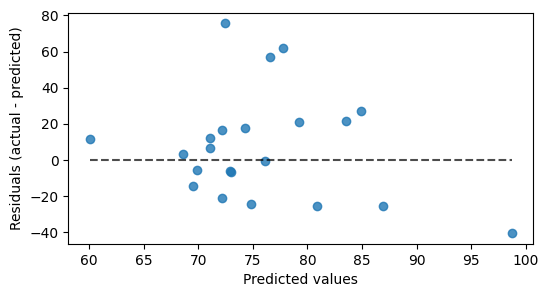

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
error_disp = PredictionErrorDisplay.from_estimator(model, X_test, y_test, ax=ax)

## Analisis descriptivo de las variables principales 

In [10]:
indices = np.argsort(model.feature_importances_)[::-1][:5]
print('\nCOLUMNAS PRINCIPALES PARA EL MODELO DE REGRESION:')
X.columns[indices]


COLUMNAS PRINCIPALES PARA EL MODELO DE REGRESION:


Index(['evapotranspiration', 'wind_gusts_max', 'fuel_stress', 'pressure_mean',
       'dry_fuel_index'],
      dtype='str')

In [11]:
print('\nANALISIS DESCRIPTIVO DE LAS VARIABLES PRINCIPALES:')
X[X.columns[indices]].describe()


ANALISIS DESCRIPTIVO DE LAS VARIABLES PRINCIPALES:


,evapotranspiration,wind_gusts_max,fuel_stress,pressure_mean,dry_fuel_index
count,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
mean,5.638332,41.595953,0.843325,968.473741,0.932980
std,2.232889,13.168684,0.374804,44.854258,0.814901
min,0.440000,14.000000,-1.000000,718.400000,-0.221370
25%,4.000000,32.400000,0.568475,944.025000,0.353499
50%,5.890000,40.000000,0.810147,982.700000,0.666943
75%,7.170000,48.600000,1.125933,1001.775000,1.285848
max,12.360000,106.200000,1.719359,1039.000000,5.260279
